<a href="https://colab.research.google.com/github/mufadah/2026_VisiKomputer/blob/main/Jobsheet2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praktikum D1

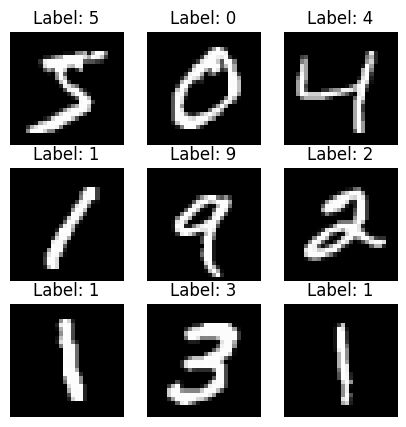

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

#Praktikum D2

In [16]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='linear', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)

print("Akurasi:", accuracy_score(y_test, y_pred))


Akurasi: 0.9101


#Praktikum D3

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9459 - loss: 0.1817 - val_accuracy: 0.9817 - val_loss: 0.0690
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9813 - loss: 0.0615 - val_accuracy: 0.9863 - val_loss: 0.0541
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9871 - loss: 0.0413 - val_accuracy: 0.9857 - val_loss: 0.0548
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9903 - loss: 0.0299 - val_accuracy: 0.9868 - val_loss: 0.0509
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9927 - loss: 0.0214 - val_accuracy: 0.9882 - val_loss: 0.0484


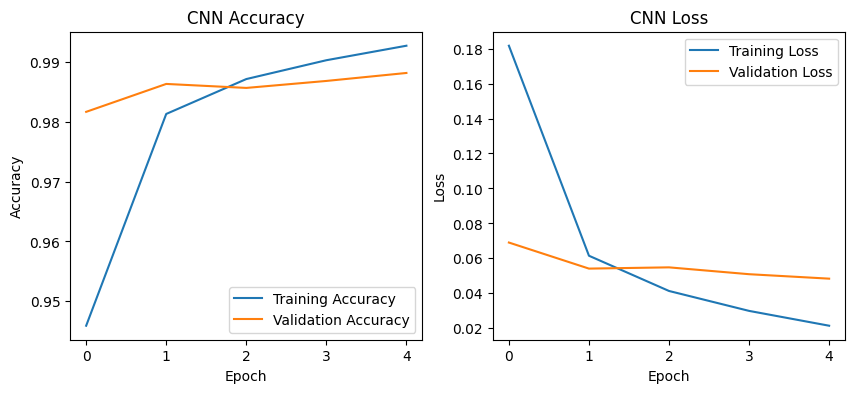

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn = x_test.reshape(-1,28,28,1) / 255.0
model = models.Sequential([
  layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
  layers.MaxPooling2D((2,2)),
  layers.Flatten(),
  layers.Dense(64, activation='relu'),
  layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


#Praktikum D4

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 25ms/step - accuracy: 0.4581 - loss: 1.5070 - val_accuracy: 0.5396 - val_loss: 1.3013
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.5880 - loss: 1.1633 - val_accuracy: 0.6370 - val_loss: 1.0486
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.6404 - loss: 1.0273 - val_accuracy: 0.6528 - val_loss: 1.0008
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.6716 - loss: 0.9375 - val_accuracy: 0.6778 - val_loss: 0.9380
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.6982 - loss: 0.8723 - val_accuracy: 0.6758 - val_loss: 0.9501
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.7150 - loss: 0.8185 - val_accuracy: 0.6924 - val_loss: 0.9171
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.7299 - loss: 0.7721 - val_accuracy: 0.6724 - val_loss: 0.9589
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accuracy: 0.7456 -

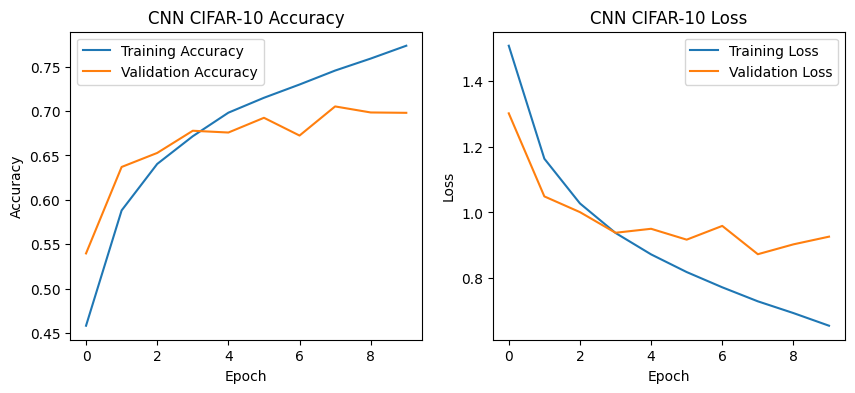

In [18]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    # Tugas kecil: Tambahkan layers.Dropout(0.5) di sini untuk mengatasi overfitting
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Praktikum D5

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 392s 278ms/step - accuracy: 0.5162 - loss: 1.3889 - val_accuracy: 0.5764 - val_loss: 1.2216
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 443s 279ms/step - accuracy: 0.5808 - loss: 1.2001 - val_accuracy: 0.5902 - val_loss: 1.1781
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 390s 277ms/step - accuracy: 0.6002 - loss: 1.1449 - val_accuracy: 0.6024 - val_loss: 1.1367
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 390s 278ms/step - accuracy: 0.6132 - loss: 1.1048 - val_accuracy: 0.6038 - val_loss: 1.1342
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 442s 277ms/step - accuracy: 0.6257 - loss: 1.0693 - val_accuracy: 0.6018 - val_loss: 1.1151


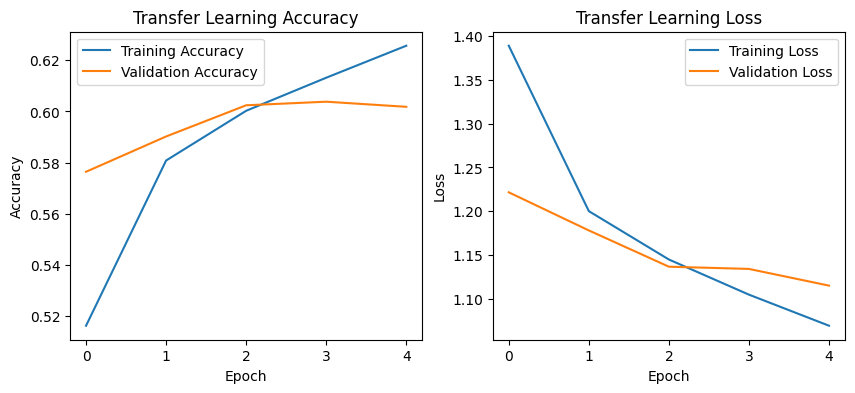

In [19]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False
# Tugas kecil: Anda bisa mengatur base_model.trainable = True lalu membekukan sebagian
# layer awalnya untuk melakukan fine-tuning.

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Praktikum D6

313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 247ms/step
              precision    recall  f1-score   support

           0       0.74      0.59      0.66      1000
           1       0.64      0.67      0.65      1000
           2       0.59      0.43      0.50      1000
           3       0.38      0.51      0.43      1000
           4       0.61      0.48      0.53      1000
           5       0.59      0.43      0.50      1000
           6       0.58      0.73      0.65      1000
           7       0.62      0.71      0.66      1000
           8       0.63      0.80      0.71      1000
           9       0.63      0.60      0.61      1000

    accuracy                           0.59     10000
   macro avg       0.60      0.59      0.59     10000
weighted avg       0.60      0.59      0.59     10000



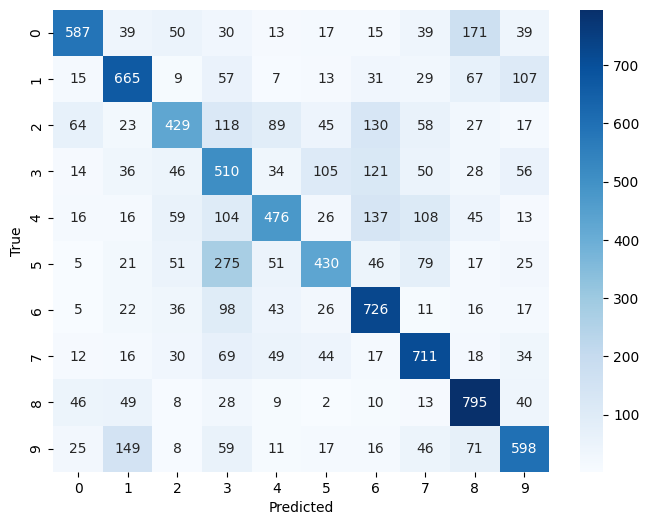

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test).argmax(axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#Penugasan (Mencoba Klasifikasi Tulisan Angka)

In [23]:
# ===== 1) Upload file foto tulisan angka =====
from google.colab import files
uploaded = files.upload() # pilih 1 atau lebih file gambar (jpg/png)

# ===== 2) Utilitas Preprocess agar mirip MNIST (28x28, putih-di-atas-hitam) =====
import numpy as np
from PIL import Image, ImageOps

def preprocess_to_mnist_28x28(img_pil):
    # Grayscale + autocontrast
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)
    arr = np.array(img).astype(np.uint8)

    # Jika rata-rata terang (kertas putih), invert supaya digit menjadi putih di atas latar gelap
    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    # Binarisasi ringan untuk cari bbox digit
    thr = np.mean(arr) * 0.8
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        img = img.crop((x0, y0, x1+1, y1+1))

    # Resize ke 20x20 dengan aspect ratio
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    w, h = img.size

    # Pad ke 28x28 dan center
    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(img, ((28-w)//2, (28-h)//2))

    # Normalisasi ke [0,1]
    arr = np.array(canvas).astype('float32') / 255.0

    # Tambah channel dim (28,28,1)
    arr = arr[..., None]

    return canvas, arr

Saving photo1.jpeg to photo1.jpeg


Menggunakan Model CNN

In [26]:
from sklearn.metrics import accuracy_score

results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)
    disp, x = preprocess_to_mnist_28x28(img_pil) # x: (28,28,1) float [0,1]

    x_flat = x.reshape(1, -1) # (1,784)
    pred = int(clf.predict(x_flat)[0])

    conf = None
    try:
        if hasattr(clf, "predict_proba"):
            conf = float(np.max(clf.predict_proba(x_flat)))
    except Exception:
        pass

    results.append((fname, pred, conf))

    # Tampilkan hasil
    print(f"{fname} -> Prediksi SVM: {pred}" + (f" (p={conf:.2f})" if conf is not None else ""))

photo1.jpeg -> Prediksi SVM: 5
